<a href="https://colab.research.google.com/github/FelipeFranciscoFerreira/Roteamento-Van-Otimizacao/blob/main/RoteamentoGenetico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from numpy import random

"""
Celula que  implementa a Fase 1 do projeto: Preparação de Dados.
O objetivo é criar uma estrutura flexível para carregar diferentes cenários de teste
sem precisar alterar a lógica principal do algoritmo genético.
"""

#Classe para agrupar as informações de um cenário de teste X
class Cenario:
    """
    Esta classe Cenario encapsula todos os dados necessários para rodar uma simulação.
    Funciona como um contêiner organizado para cada um dos exemplos.
    """
    def __init__(self, nome, pontos, distancias, velocidades, tempos, janelas_escola,
                 alunos_do_dia, escolas_do_dia):
        self.nome: str = nome
        self.pontos: dict = pontos              # {ID: "Nome do Ponto"}
        self.distancias: np.ndarray = distancias # Matriz de distâncias (em km)
        self.velocidades: np.ndarray = velocidades # Matriz de velocidades (em km/min)
        self.tempos: np.ndarray = tempos        # Matriz de tempos de viagem (em minutos)
        self.janelas_escola: dict = janelas_escola # {ID_Escola: (inicio, fim)} em minutos
        self.alunos_do_dia: list = alunos_do_dia
        self.escolas_do_dia: list = escolas_do_dia

In [ ]:
def _gerar_cenario_pequeno_estatico():
    """
    Cria e retorna um cenário de teste pequeno com dados fixos (estáticos).
    Ideal para depuração e testes rápidos e controlados.
    """
    nome = "Cenário Pequeno Estático (5 Alunos, 2 Escolas)"
    pontos = {
        0: "Garagem", 1: "Aluno A", 2: "Aluno B", 3: "Aluno C", 4: "Aluno D", 5: "Aluno E",
        6: "Escola X", 7: "Escola Y"
    }
    distancias = np.array([
        [0, 5, 8, 10, 12, 15, 20, 25], [5, 0, 4, 9, 11, 14, 18, 23],
        [8, 4, 0, 6, 8, 10, 15, 20], [10, 9, 6, 0, 3, 5, 12, 18],
        [12, 11, 8, 3, 0, 2, 10, 16], [15, 14, 10, 5, 2, 0, 8, 14],
        [20, 18, 15, 12, 10, 8, 0, 6], [25, 23, 20, 18, 16, 14, 6, 0]
    ])
    # Velocidades em km/min (ex: 0.5 km/min = 30 km/h)
    velocidades = np.array([
        [1, 0.4, 0.5, 0.6, 0.5, 0.7, 0.8, 0.9], [0.4, 1, 0.3, 0.5, 0.6, 0.5, 0.7, 0.8],
        [0.5, 0.3, 1, 0.4, 0.4, 0.5, 0.6, 0.7], [0.6, 0.5, 0.4, 1, 0.5, 0.6, 0.7, 0.8],
        [0.5, 0.6, 0.4, 0.5, 1, 0.4, 0.6, 0.7], [0.7, 0.5, 0.5, 0.6, 0.4, 1, 0.5, 0.6],
        [0.8, 0.7, 0.6, 0.7, 0.6, 0.5, 1, 0.8], [0.9, 0.8, 0.7, 0.8, 0.7, 0.6, 0.8, 1]
    ])
    # Evita divisão por zero na diagonal principal
    np.fill_diagonal(velocidades, 1)
    tempos = distancias / velocidades

    janelas_escola = {6: (450, 470), 7: (465, 480)}
    alunos_do_dia = [1, 2, 3, 4, 5]
    escolas_do_dia = [6, 7]

    return Cenario(nome, pontos, distancias, velocidades, tempos, janelas_escola, alunos_do_dia, escolas_do_dia)

In [ ]:
def _gerar_cenario_pequeno_aleatorio():
    """Cria e retorna um cenário pequeno com dados gerados aleatoriamente."""
    nome = "Cenário Pequeno Aleatório (8 Alunos, 2 Escolas)"
    n_alunos, n_escolas = 8, 2
    n_pontos = 1 + n_alunos + n_escolas
    pontos = {0: "Garagem"}
    for i in range(n_alunos): pontos[i + 1] = f"Aluno {i + 1}"
    for i in range(n_escolas): pontos[1 + n_alunos + i] = f"Escola {i + 1}"

    distancias = np.zeros((n_pontos, n_pontos), dtype=int)
    velocidades = np.zeros((n_pontos, n_pontos), dtype=float)
    for i in range(n_pontos):
        for j in range(i + 1, n_pontos):
            dist = random.randint(5, 50)
            distancias[i, j] = distancias[j, i] = dist
            # Velocidade aleatória entre 0.3 (18km/h) e 1.0 (60km/h) km/min
            vel = random.uniform(0.3, 1.0)
            velocidades[i, j] = velocidades[j, i] = vel

    np.fill_diagonal(velocidades, 1)
    tempos = distancias / velocidades

    janelas_escola = {}
    for i in range(n_escolas):
        id_escola = 1 + n_alunos + i
        inicio = random.randint(440, 460)
        janelas_escola[id_escola] = (inicio, inicio + 20)

    alunos_do_dia = list(range(1, n_alunos + 1))
    escolas_do_dia = list(range(n_alunos + 1, n_pontos))
    return Cenario(nome, pontos, distancias, velocidades, tempos, janelas_escola, alunos_do_dia, escolas_do_dia)

In [ ]:
def _gerar_cenario_medio_estatico():
    """Cria e retorna um cenário médio com dados 'aleatórios', mas fixos (usando seed)."""
    nome = "Cenário Médio Estático (20 Alunos, 3 Escolas)"
    # A seed garante que os números "aleatórios" sejam sempre os mesmos
    random.seed(42)
    n_alunos, n_escolas = 20, 3
    n_pontos = 1 + n_alunos + n_escolas
    # O restante da lógica é igual ao aleatório, mas a seed o torna repetível
    pontos = {0: "Garagem"}
    for i in range(n_alunos): pontos[i + 1] = f"Aluno {i + 1}"
    for i in range(n_escolas): pontos[1 + n_alunos + i] = f"Escola {i + 1}"

    distancias = np.zeros((n_pontos, n_pontos), dtype=int)
    velocidades = np.zeros((n_pontos, n_pontos), dtype=float)
    for i in range(n_pontos):
        for j in range(i + 1, n_pontos):
            dist = random.randint(5, 100)
            distancias[i, j] = distancias[j, i] = dist
            vel = random.uniform(0.3, 1.0)
            velocidades[i, j] = velocidades[j, i] = vel

    np.fill_diagonal(velocidades, 1)
    tempos = distancias / velocidades

    janelas_escola = {}
    for i in range(n_escolas):
        id_escola = 1 + n_alunos + i
        inicio = random.randint(440, 460)
        janelas_escola[id_escola] = (inicio, inicio + 25)

    alunos_do_dia = list(range(1, n_alunos + 1))
    escolas_do_dia = list(range(n_alunos + 1, n_pontos))
    # Reseta a seed para não afetar outras partes aleatórias do programa
    random.seed(None)
    return Cenario(nome, pontos, distancias, velocidades, tempos, janelas_escola, alunos_do_dia, escolas_do_dia)

In [ ]:
def _gerar_cenario_medio_aleatorio():
    """Cria e retorna um cenário médio com dados totalmente aleatórios."""
    nome = "Cenário Médio Aleatório (25 Alunos, 4 Escolas)"
    random.seed(None) # Garante aleatoriedade real
    n_alunos, n_escolas = 25, 4
    n_pontos = 1 + n_alunos + n_escolas
    pontos = {0: "Garagem"}
    for i in range(n_alunos): pontos[i + 1] = f"Aluno {i + 1}"
    for i in range(n_escolas): pontos[1 + n_alunos + i] = f"Escola {i + 1}"

    distancias = np.zeros((n_pontos, n_pontos), dtype=int)
    velocidades = np.zeros((n_pontos, n_pontos), dtype=float)
    for i in range(n_pontos):
        for j in range(i + 1, n_pontos):
            dist = random.randint(5, 100)
            distancias[i, j] = distancias[j, i] = dist
            vel = random.uniform(0.3, 1.0)
            velocidades[i, j] = velocidades[j, i] = vel

    np.fill_diagonal(velocidades, 1)
    tempos = distancias / velocidades

    janelas_escola = {}
    for i in range(n_escolas):
        id_escola = 1 + n_alunos + i
        inicio = random.randint(440, 470)
        janelas_escola[id_escola] = (inicio, inicio + 20)

    alunos_do_dia = list(range(1, n_alunos + 1))
    escolas_do_dia = list(range(n_alunos + 1, n_pontos))
    return Cenario(nome, pontos, distancias, velocidades, tempos, janelas_escola, alunos_do_dia, escolas_do_dia)

In [ ]:
def _gerar_cenario_gigantesco():
    """
    Cria e retorna um cenário de teste massivo com 200 alunos e 10 escolas.
    """
    nome = "Cenário Gigantesco (200 Alunos, 10 Escolas)"
    n_alunos = 200
    n_escolas = 10
    n_pontos = 1 + n_alunos + n_escolas

    print(f"Iniciando geração do cenário '{nome}'... Isso pode levar um momento.")

    pontos = {0: "Garagem"}
    for i in range(n_alunos):
        pontos[i + 1] = f"Aluno {i + 1}"
    for i in range(n_escolas):
        pontos[1 + n_alunos + i] = f"Escola {i + 1}"

    # Gera distâncias e velocidades aleatórias
    distancias = np.zeros((n_pontos, n_pontos), dtype=np.int16)
    velocidades = np.zeros((n_pontos, n_pontos), dtype=np.float32)

    for i in range(n_pontos):
        for j in range(i + 1, n_pontos):
            dist = random.randint(5, 200) # Aumentando a dispersão das distâncias
            distancias[i, j] = distancias[j, i] = dist
            vel = random.uniform(0.3, 1.0) # km/min
            velocidades[i, j] = velocidades[j, i] = vel

    np.fill_diagonal(velocidades, 1) # Evita divisão por zero
    # Usamos np.divide para evitar erros de tipo com arrays grandes
    tempos = np.divide(distancias, velocidades, where=velocidades!=0)

    # Gera janelas de tempo aleatórias para as escolas
    janelas_escola = {}
    for i in range(n_escolas):
        id_escola = 1 + n_alunos + i
        inicio = random.randint(440, 480) # Início entre 07:20 e 08:00
        janelas_escola[id_escola] = (inicio, inicio + 30) # Janela de 30 min

    alunos_do_dia = list(range(1, n_alunos + 1))
    escolas_do_dia = list(range(n_alunos + 1, n_pontos))

    print("Geração do cenário gigantesco concluída.")
    return Cenario(nome, pontos, distancias, velocidades, tempos, janelas_escola, alunos_do_dia, escolas_do_dia)


In [ ]:
#  O BANCO DE DADOS DE CENÁRIOS

banco_de_cenarios = {
    "pequeno_estatico": _gerar_cenario_pequeno_estatico(),
    "pequeno_aleatorio": _gerar_cenario_pequeno_aleatorio(),
    "medio_estatico": _gerar_cenario_medio_estatico(),
    "medio_aleatorio": _gerar_cenario_medio_aleatorio(),
    "gigantesco": _gerar_cenario_gigantesco(),
}

# PASSO 4: A FUNÇÃO DE CARREGAMENTO

def carregar_cenario(nome_do_cenario: str) -> Cenario:
    """Busca um cenário no banco de dados pelo nome e o retorna."""
    try:
        print(f"Carregando cenário: '{nome_do_cenario}'...")
        return banco_de_cenarios[nome_do_cenario]
    except KeyError:
        print(f"ERRO: Cenário '{nome_do_cenario}' não encontrado!")
        print(f"Cenários disponíveis: {list(banco_de_cenarios.keys())}")
        exit()

Iniciando geração do cenário 'Cenário Gigantesco (200 Alunos, 10 Escolas)'... Isso pode levar um momento.
Geração do cenário gigantesco concluída.


In [ ]:
if __name__ == '__main__':
    # CÉLULA SOMENTE PARA TESTE DOS DADOS DOS CENÁRIOS
    # >>>>> PARA TROCAR DE CENÁRIO, MUDE APENAS A LINHA ABAIXO <<<<<
    #
    CENARIO_ESCOLHIDO = "gigantesco"

    cenario_atual = carregar_cenario(CENARIO_ESCOLHIDO)

    print(f"\nNome do Cenário: {cenario_atual.nome}")
    print(f"Alunos do dia: {cenario_atual.alunos_do_dia}")

    ponto1_id, ponto2_id = 0, 1
    ponto1_nome = cenario_atual.pontos[ponto1_id]
    ponto2_nome = cenario_atual.pontos[ponto2_id]

    print(f"\nExemplo de consulta entre '{ponto1_nome}' e '{ponto2_nome}':")
    dist = cenario_atual.distancias[ponto1_id, ponto2_id]
    print(f"  - Distância: {dist} km.")

    vel = cenario_atual.velocidades[ponto1_id, ponto2_id]
    print(f"  - Velocidade Média: {vel * 60:.2f} km/h.") # Convertendo de km/min para km/h

    tempo = cenario_atual.tempos[ponto1_id, ponto2_id]
    print(f"  - Tempo de Viagem: {tempo:.2f} minutos.")

Carregando cenário: 'gigantesco'...

Nome do Cenário: Cenário Gigantesco (200 Alunos, 10 Escolas)
Alunos do dia: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199,

In [ ]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
import sys

"""
A partir daqui começa o Algorítmo Genético
"""

#Primeiro precisa fazer o setup dos dados
# Assumimos que a função 'carregar_cenario' e a classe 'Cenario' já existem
# na memória do Colab por terem sido executadas em uma célula anterior.

# >>>>> PARA TROCAR DE CENÁRIO, MUDE APENAS A LINHA ABAIXO <<<<<
CENARIO_ESCOLHIDO = "gigantesco"
cenario = carregar_cenario(CENARIO_ESCOLHIDO)

Carregando cenário: 'gigantesco'...


In [ ]:
# CELULA DE PARAMETROS
#  PARÂMETROS DO AG (baseados no cenário carregado)
# Tamanho do cromossomo é definido dinamicamente
TAM_CROMO_COLETA = len(cenario.alunos_do_dia)
TAM_CROMO_ENTREGA = len(cenario.escolas_do_dia)
TAM_CROMO_TOTAL = TAM_CROMO_COLETA + TAM_CROMO_ENTREGA

# Parâmetros de execução do AG
TAM_POP = 2000
N_GERACOES = 500
TAXA_CRUZAMENTO = 0.85
TAXA_MUTACAO = 0.03
N_ELITISMO = 4

# Parâmetros da Função de Aptidão
HORA_SAIDA_GARAGEM = 420 # 07:00 em minutos
TEMPO_PARADA_ALUNO = 2 # minutos
TEMPO_PARADA_ESCOLA = 5 # minutos
PESO_DISTANCIA = 0.8 # Importância da distância
PENALIDADE_ATRASO = 100.0 # Penalidade altíssima por cada minuto de atraso

# Variáveis globais para o AG
pop = np.zeros((TAM_POP, TAM_CROMO_TOTAL), dtype=int)
nova_pop = np.zeros((TAM_POP, TAM_CROMO_TOTAL), dtype=int)
pais = np.zeros((2, TAM_CROMO_TOTAL), dtype=int)
filhos = np.zeros((2, TAM_CROMO_TOTAL), dtype=int)
# Coluna 0: índice original, Coluna 1: fitness, Coluna 2: prob. de seleção
nota_pop = np.zeros((TAM_POP, 3))

In [ ]:
# FUNÇÕES DO MOTOR DO ALGORITMO GENÉTICO


def init_pop():
    """Inicializa a população com cromossomos dinâmicos e válidos."""
    global pop
    for i in range(TAM_POP):
        ordem_coleta = np.random.permutation(cenario.alunos_do_dia)
        ordem_entrega = np.random.permutation(cenario.escolas_do_dia)
        pop[i] = np.concatenate((ordem_coleta, ordem_entrega))


In [ ]:

# Celula de Função de Aptidão

def avalia_pop():
    """
    A função de aptidão. Para cada indivíduo, simula a rota, calcula
    distância e penalidades, e retorna um 'fitness' (custo) total.
    O objetivo é MINIMIZAR este valor.
    """
    global nota_pop
    soma_apt_inversa = 0

    for i in range(TAM_POP):
        cromossomo = pop[i]
        rota_completa = np.concatenate(([0], cromossomo, [0])).astype(int)

        # Início da simulação
        horario_atual = HORA_SAIDA_GARAGEM
        distancia_total = 0.0
        atraso_total = 0.0

        for j in range(len(rota_completa) - 1):
            ponto_origem = rota_completa[j]
            ponto_destino = rota_completa[j+1]

            # 1. Acumula distância e tempo de viagem
            distancia_total += cenario.distancias[ponto_origem, ponto_destino]
            horario_atual += cenario.tempos[ponto_origem, ponto_destino]

            # 2. Adiciona tempo de parada e verifica janelas de tempo
            if ponto_destino in cenario.escolas_do_dia:
                janela_inicio, janela_fim = cenario.janelas_escola[ponto_destino]

                # Chegou cedo? A van espera.
                if horario_atual < janela_inicio:
                    horario_atual = janela_inicio

                # Chegou atrasado? Calcula a penalidade.
                elif horario_atual > janela_fim:
                    atraso_total += (horario_atual - janela_fim)

                horario_atual += TEMPO_PARADA_ESCOLA

            elif ponto_destino in cenario.alunos_do_dia:
                horario_atual += TEMPO_PARADA_ALUNO

        # 3. Calcula o fitness (custo) final
        fitness = (PESO_DISTANCIA * distancia_total) + (PENALIDADE_ATRASO * atraso_total)

        nota_pop[i, 0] = i
        nota_pop[i, 1] = fitness
        if fitness > 0:
            soma_apt_inversa += 1 / fitness

    # Ordena a população pelo fitness (do melhor para o pior)
    nota_pop = nota_pop[nota_pop[:, 1].argsort()]

    # Calcula a probabilidade de seleção (método da roleta)
    acum_prob = 0
    for i in range(TAM_POP):
        if nota_pop[i, 1] > 0 and soma_apt_inversa > 0:
            prob = (1 / nota_pop[i, 1]) / soma_apt_inversa
        else:
            prob = 0
        nota_pop[i, 2] = prob
        acum_prob += prob

    # Normaliza as probabilidades para somarem 1
    if acum_prob > 0:
        nota_pop[:, 2] /= acum_prob

In [ ]:

# Celula para TODOS os Operadores Genéticos:
# seleciona_pais
# ordered_crossover
# cruza_pais
# muta_filhos
# elitismo

def seleciona_pais():
    """Seleciona dois pais usando o método da Roleta."""
    global pais
    for i in range(2):
        ponto_sorteado = random.random()
        acum_prob = 0
        for j in range(TAM_POP):
            acum_prob += nota_pop[j, 2]
            if acum_prob >= ponto_sorteado:
                indice_pai = int(nota_pop[j, 0])
                pais[i] = pop[indice_pai]
                break

def ordered_crossover(pai1, pai2):
    """Função auxiliar para o cruzamento ordenado (OX1)."""
    tamanho = len(pai1)
    filho = np.full(tamanho, -1, dtype=int)
    inicio, fim = sorted(random.choice(range(tamanho + 1), 2, replace=False))
    filho[inicio:fim] = pai1[inicio:fim]
    genes_pai2 = [gene for gene in pai2 if gene not in filho]
    idx_genes = 0
    for i in range(tamanho):
        if filho[i] == -1:
            filho[i] = genes_pai2[idx_genes]
            idx_genes += 1
    return filho

def cruza_pais():
    """Aplica o Ordered Crossover separadamente na coleta e na entrega."""
    global filhos
    if random.random() < TAXA_CRUZAMENTO:
        coleta_p1, coleta_p2 = pais[0, :TAM_CROMO_COLETA], pais[1, :TAM_CROMO_COLETA]
        entrega_p1, entrega_p2 = pais[0, TAM_CROMO_COLETA:], pais[1, TAM_CROMO_COLETA:]
        coleta_f1 = ordered_crossover(coleta_p1, coleta_p2)
        coleta_f2 = ordered_crossover(coleta_p2, coleta_p1)
        entrega_f1 = ordered_crossover(entrega_p1, entrega_p2)
        entrega_f2 = ordered_crossover(entrega_p2, entrega_p1)
        filhos[0] = np.concatenate((coleta_f1, entrega_f1))
        filhos[1] = np.concatenate((coleta_f2, entrega_f2))
    else:
        filhos[:] = pais

def muta_filhos():
    """Aplica a Mutação por Troca (Swap Mutation)."""
    global filhos
    for i in range(2):
        # Mutação na parte de coleta
        if random.random() < TAXA_MUTACAO:
            idx1, idx2 = random.choice(range(TAM_CROMO_COLETA), 2, replace=False)
            filhos[i, idx1], filhos[i, idx2] = filhos[i, idx2], filhos[i, idx1]
        # Mutação na parte de entrega
        if random.random() < TAXA_MUTACAO and TAM_CROMO_ENTREGA > 1:
            idx1, idx2 = random.choice(range(TAM_CROMO_ENTREGA), 2, replace=False)
            offset = TAM_CROMO_COLETA
            filhos[i, offset+idx1], filhos[i, offset+idx2] = filhos[i, offset+idx2], filhos[i, offset+idx1]

def elitismo(qtde):
    """Preserva os 'qtde' melhores indivíduos para a próxima geração."""
    global nova_pop
    for i in range(qtde):
        indice_melhor = int(nota_pop[i, 0])
        nova_pop[i] = pop[indice_melhor]

--- INICIANDO OTIMIZADOR DE ROTAS COM ALGORITMO GENÉTICO ---
Cenário carregado: Cenário Gigantesco (200 Alunos, 10 Escolas)

Geração 0: Melhor Custo (Fitness) = 31093675.60
Geração 1: Melhor Custo (Fitness) = 31028871.20
Geração 2: Melhor Custo (Fitness) = 30714109.60
Geração 3: Melhor Custo (Fitness) = 29540178.80
Geração 4: Melhor Custo (Fitness) = 29540178.80
Geração 5: Melhor Custo (Fitness) = 29540178.80
Geração 6: Melhor Custo (Fitness) = 29540178.80
Geração 7: Melhor Custo (Fitness) = 29540178.80
Geração 8: Melhor Custo (Fitness) = 29540178.80
Geração 9: Melhor Custo (Fitness) = 29540178.80
Geração 10: Melhor Custo (Fitness) = 29540178.80
Geração 11: Melhor Custo (Fitness) = 29540178.80
Geração 12: Melhor Custo (Fitness) = 28978599.20
Geração 13: Melhor Custo (Fitness) = 28978599.20
Geração 14: Melhor Custo (Fitness) = 28978599.20
Geração 15: Melhor Custo (Fitness) = 28978599.20
Geração 16: Melhor Custo (Fitness) = 28978599.20
Geração 17: Melhor Custo (Fitness) = 28978599.20
Ger

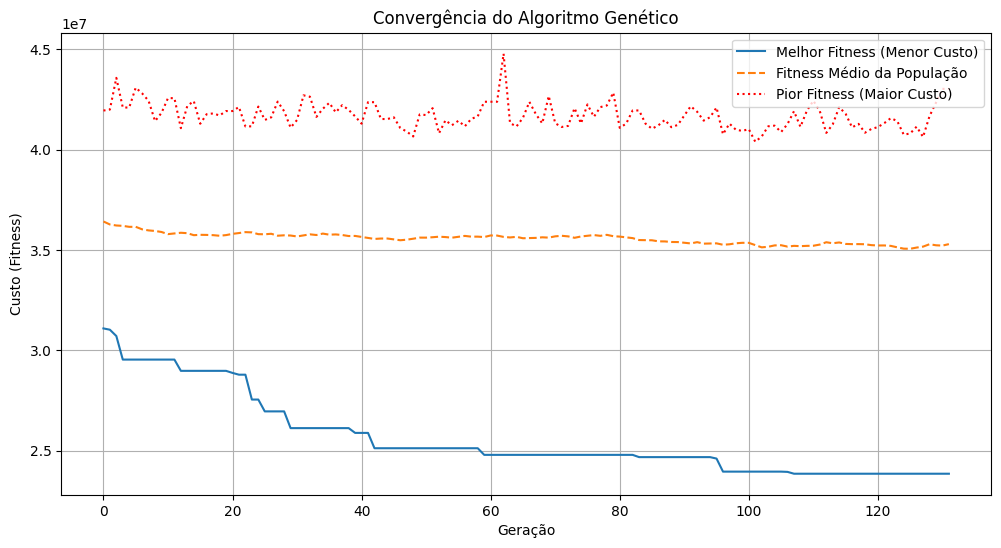

In [ ]:
# ADICIONADO: Importamos a biblioteca 'time' para medir o tempo
import time

# (O resto de suas funções e imports, como 'traduzir_rota_para_nomes', etc.)
def traduzir_rota_para_nomes(rota_ids):
    """Função auxiliar para imprimir a rota com nomes legíveis."""
    # Pequena correção para incluir a garagem no início e fim da rota traduzida
    rota_completa = np.concatenate(([0], rota_ids, [0]))
    return " -> ".join([cenario.pontos[int(p)] for p in rota_completa])

if __name__ == '__main__':
    # ADICIONADO: Marcamos o tempo de início da execução.
    tempo_inicio = time.time()

    print("--- INICIANDO OTIMIZADOR DE ROTAS COM ALGORITMO GENÉTICO ---")
    print(f"Cenário carregado: {cenario.nome}\n")
    GERACOES_SEM_MELHORA = 25 # Nº de gerações sem melhoria para parar
    TOLERANCIA = 1e-6
    # MODIFICADO: Criamos uma lista para armazenar também o fitness do pior indivíduo.
    geracoes_plot, melhor_fitness_plot, media_fitness_plot, pior_fitness_plot = [], [], [], []

# --- ADICIONADO: Inicialização das variáveis de controle ---
    geracoes_parado = 0
    # Assumindo minimização (custo), iniciamos com infinito
    melhor_fitness_global = float('inf')
    parou_por_convergencia = False # Flag para saber por que parou

    # Início do processo evolucionário
    init_pop()

    for i in range(N_GERACOES):
        avalia_pop()
        # --- ADICIONADO: Lógica de Verificação de Convergência ---
        melhor_fitness_atual = nota_pop[0, 1]

        # Como é minimização (custo), verificamos se o fitness atual é *menor* que o global
        if (melhor_fitness_global - melhor_fitness_atual) > TOLERANCIA:
            melhor_fitness_global = melhor_fitness_atual
            geracoes_parado = 0  # Reseta a contagem
        else:
            geracoes_parado += 1 # Incrementa se não houver melhoria

        # Verifica se deve parar
        if geracoes_parado >= GERACOES_SEM_MELHORA:
            parou_por_convergencia = True
            print(f"\nParando na Geração {i}: Convergência atingida.") # Feedback imediato
            break # --- SAI DO LOOP 'for' ---
        # --- Fim da Lógica de Convergência ---
        # Guarda dados para o gráfico
        geracoes_plot.append(i)
        melhor_fitness_plot.append(nota_pop[0, 1])
        media_fitness_plot.append(np.mean(nota_pop[:, 1]))
        # ADICIONADO: Armazenamos o fitness do pior indivíduo da geração.
        # Como a 'nota_pop' está ordenada do melhor para o pior, o pior é sempre o último.
        pior_fitness_plot.append(nota_pop[-1, 1])

        # Imprime o progresso a cada 100 gerações
        if i % 1 == 0:
            print(f"Geração {i}: Melhor Custo (Fitness) = {nota_pop[0, 1]:.2f}")

        # Processo de criação da nova geração
        elitismo(N_ELITISMO)
        j = N_ELITISMO
        while j < TAM_POP:
            seleciona_pais()
            cruza_pais()
            muta_filhos()
            nova_pop[j] = filhos[0]
            if j + 1 < TAM_POP:
                nova_pop[j+1] = filhos[1]
            j += 2
        pop = nova_pop.copy()

    # Avalia a população final para obter o melhor resultado
    avalia_pop()
    print("\n--- OTIMIZAÇÃO CONCLUÍDA ---")
    # --- ADICIONADO: Informa o motivo da parada ---
    if parou_por_convergencia:
        print(f"Parada por convergência: Sem melhoria por {GERACOES_SEM_MELHORA} gerações.")
    else:
        # Se o loop terminou sem 'break', foi por atingir o limite
        print(f"Parada por limite: Atingiu {N_GERACOES} gerações.")

    # ADICIONADO: Calculamos e imprimimos o tempo total de execução.
    tempo_fim = time.time()
    print(f"\nTempo de Execução: {tempo_fim - tempo_inicio:.2f} segundos")

    # Apresenta a melhor rota encontrada
    melhor_cromossomo = pop[int(nota_pop[0, 0])]

    print(f"\nMelhor Rota (Nomes):\n{traduzir_rota_para_nomes(melhor_cromossomo)}")
    print(f"\nCusto Final (Fitness): {nota_pop[0, 1]:.2f}")

    # Plota o gráfico de convergência
    plt.figure(figsize=(12, 6))
    plt.plot(geracoes_plot, melhor_fitness_plot, label="Melhor Fitness (Menor Custo)")
    plt.plot(geracoes_plot, media_fitness_plot, label="Fitness Médio da População", linestyle='--')
    # ADICIONADO: Adicionamos a linha do pior fitness ao gráfico.
    plt.plot(geracoes_plot, pior_fitness_plot, label="Pior Fitness (Maior Custo)", linestyle=':', color='red')
    plt.title("Convergência do Algoritmo Genético")
    plt.xlabel("Geração")
    plt.ylabel("Custo (Fitness)")
    plt.legend()
    plt.grid(True)
    plt.show()

